# Decision Tree

In [2]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn import preprocessing



In [3]:
# Uploading dataset

In [4]:
heart_df= pd.read_excel(r'C:\Users\Smrithi\Documents\ExcelR\Assignments_answer_by_me\Decision Tree_Ass8\heart_disease.xlsx',sheet_name="Heart_disease", engine='openpyxl')

In [5]:
heart_df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
5,66,Male,asymptomatic,160,228,False,lv hypertrophy,138,False,2.3,upsloping,fixed defect,0
6,56,Male,non-anginal,130,276,False,normal,128,True,1.0,upsloping,fixed defect,0
7,48,Male,non-anginal,110,211,False,normal,138,False,0.0,downsloping,fixed defect,0
8,57,Male,atypical angina,140,260,True,normal,140,False,0.0,downsloping,fixed defect,0
9,53,Male,non-anginal,155,175,True,st-t abnormality,160,False,NaN,upsloping,fixed defect,0


In [6]:
# pip install pandas openpyxl

# Install to load excel

In [7]:
# EDA

In [8]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [9]:
# object datatypes and boolean need to be converted into numerical for model building

In [10]:
# Missing value check
heart_df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [11]:
heart_df['oldpeak'].value_counts()

oldpeak
 0.0    358
 1.0     83
 2.0     76
 1.5     48
 3.0     28
 0.5     19
 1.2     17
 2.5     16
 1.4     15
 0.8     15
 0.6     14
 1.6     14
 0.2     14
 1.8     12
 0.4     10
 0.1      9
 4.0      8
 2.8      7
 2.6      7
 0.7      5
 1.9      5
 1.3      5
 2.2      5
 0.3      5
 2.4      4
 0.9      4
 1.1      4
 3.6      4
 3.4      3
-1.0      2
 3.2      2
 2.3      2
-0.5      2
 4.2      2
 2.1      2
 3.5      2
 1.7      2
-2.0      1
 4.4      1
 3.7      1
 2.9      1
 5.6      1
 6.2      1
-0.7      1
 3.1      1
-0.1      1
 5.0      1
-1.1      1
-0.8      1
-2.6      1
-0.9      1
-1.5      1
 3.8      1
Name: count, dtype: int64

In [12]:
len(heart_df['oldpeak'])

908

In [13]:
# Data imputation using median should be performed for null values

In [14]:
heart_df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [15]:
# Since the mean and median are almost same for the features, it can be interpreted that there are reduced chances of outliers

In [16]:
# Data imputation with median

In [17]:
di=heart_df['oldpeak'].median()

In [18]:
heart_df['oldpeak'].isnull().sum()

62

In [19]:
heart_df['oldpeak']=heart_df['oldpeak'].fillna(di)

In [20]:
heart_df['oldpeak'].isnull().sum()

0

In [21]:
# Null values are removed

In [22]:
# Data transformation for categorical and boolean features 

In [23]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [24]:
heart_df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0


In [25]:
heart_n = heart_df

In [26]:
heart_n = pd.get_dummies(heart_n, columns=['sex'])

In [27]:
heart_n.head(1)

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num,sex_Female,sex_Male
0,63,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0,False,True


In [28]:
heart_n = pd.get_dummies(heart_n,columns=['cp'])

In [29]:
heart_n.head(1)

,age,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0,False,True,False,False,False,True


In [30]:
heart_n = pd.get_dummies(heart_n,columns=['restecg', 'slope', 'thal'])

In [31]:
heart_n['exang'].value_counts()

exang
False    516
True     337
TURE      36
FALSE     19
Name: count, dtype: int64

In [32]:
heart_n['exang']=heart_n['exang'].replace({'TURE':'True','FALSE':'False'})

In [33]:
# heart_n = pd.get_dummies(heart_n,columns=['exang'])

In [34]:
heart_n.head(10)

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Female,sex_Male,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,145,233,True,150,False,2.3,0,False,True,...,True,True,False,False,True,False,False,True,False,False
1,41,135,203,False,132,False,0.0,0,False,True,...,False,False,True,False,False,True,False,True,False,False
2,57,140,192,False,148,False,0.4,0,False,True,...,False,False,True,False,False,True,False,True,False,False
3,52,118,186,False,190,False,0.0,0,False,True,...,True,True,False,False,False,True,False,True,False,False
4,57,110,201,False,126,True,1.5,0,False,True,...,False,False,True,False,False,True,False,True,False,False
5,66,160,228,False,138,False,2.3,0,False,True,...,False,True,False,False,False,False,True,True,False,False
6,56,130,276,False,128,True,1.0,0,False,True,...,False,False,True,False,False,False,True,True,False,False
7,48,110,211,False,138,False,0.0,0,False,True,...,False,False,True,False,True,False,False,True,False,False
8,57,140,260,True,140,False,0.0,0,False,True,...,False,False,True,False,True,False,False,True,False,False
9,53,155,175,True,160,False,0.5,0,False,True,...,False,False,False,True,False,False,True,True,False,False


In [35]:
heart_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       908 non-null    int64  
 1   trestbps                  908 non-null    int64  
 2   chol                      908 non-null    int64  
 3   fbs                       908 non-null    bool   
 4   thalch                    908 non-null    int64  
 5   exang                     908 non-null    object 
 6   oldpeak                   908 non-null    float64
 7   num                       908 non-null    int64  
 8   sex_Female                908 non-null    bool   
 9   sex_Male                  908 non-null    bool   
 10  cp_asymptomatic           908 non-null    bool   
 11  cp_atypical angina        908 non-null    bool   
 12  cp_non-anginal            908 non-null    bool   
 13  cp_typical angina         908 non-null    bool   
 14  restecg_lv

In [36]:
heart_n['exang'].value_counts()

exang
False    516
True     337
True      36
False     19
Name: count, dtype: int64

In [37]:
# Changing object datatype into numerical

In [38]:
heart_n['exang']=pd.to_numeric(heart_n['exang'], errors='coerce')

In [39]:
heart_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       908 non-null    int64  
 1   trestbps                  908 non-null    int64  
 2   chol                      908 non-null    int64  
 3   fbs                       908 non-null    bool   
 4   thalch                    908 non-null    int64  
 5   exang                     853 non-null    float64
 6   oldpeak                   908 non-null    float64
 7   num                       908 non-null    int64  
 8   sex_Female                908 non-null    bool   
 9   sex_Male                  908 non-null    bool   
 10  cp_asymptomatic           908 non-null    bool   
 11  cp_atypical angina        908 non-null    bool   
 12  cp_non-anginal            908 non-null    bool   
 13  cp_typical angina         908 non-null    bool   
 14  restecg_lv

In [40]:
heart_n['exang'].value_counts()

exang
0.0    516
1.0    337
Name: count, dtype: int64

In [41]:
heart_n.select_dtypes(exclude=['number']).columns

Index(['fbs', 'sex_Female', 'sex_Male', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_downsloping', 'slope_flat', 'slope_upsloping',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect'],
      dtype='object')

In [42]:
# Converting boolean to numeric

In [43]:
cols=['fbs', 'sex_Female', 'sex_Male', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_downsloping', 'slope_flat', 'slope_upsloping',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect']

In [44]:
heart_n[cols]=heart_n[cols].astype(int)

In [45]:
heart_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       908 non-null    int64  
 1   trestbps                  908 non-null    int64  
 2   chol                      908 non-null    int64  
 3   fbs                       908 non-null    int32  
 4   thalch                    908 non-null    int64  
 5   exang                     853 non-null    float64
 6   oldpeak                   908 non-null    float64
 7   num                       908 non-null    int64  
 8   sex_Female                908 non-null    int32  
 9   sex_Male                  908 non-null    int32  
 10  cp_asymptomatic           908 non-null    int32  
 11  cp_atypical angina        908 non-null    int32  
 12  cp_non-anginal            908 non-null    int32  
 13  cp_typical angina         908 non-null    int32  
 14  restecg_lv

In [46]:
# Data tranformation has been completed

In [47]:
# Visualization using histograms, bar plots and correlation matrix

In [48]:
import math

In [49]:
import seaborn as sns

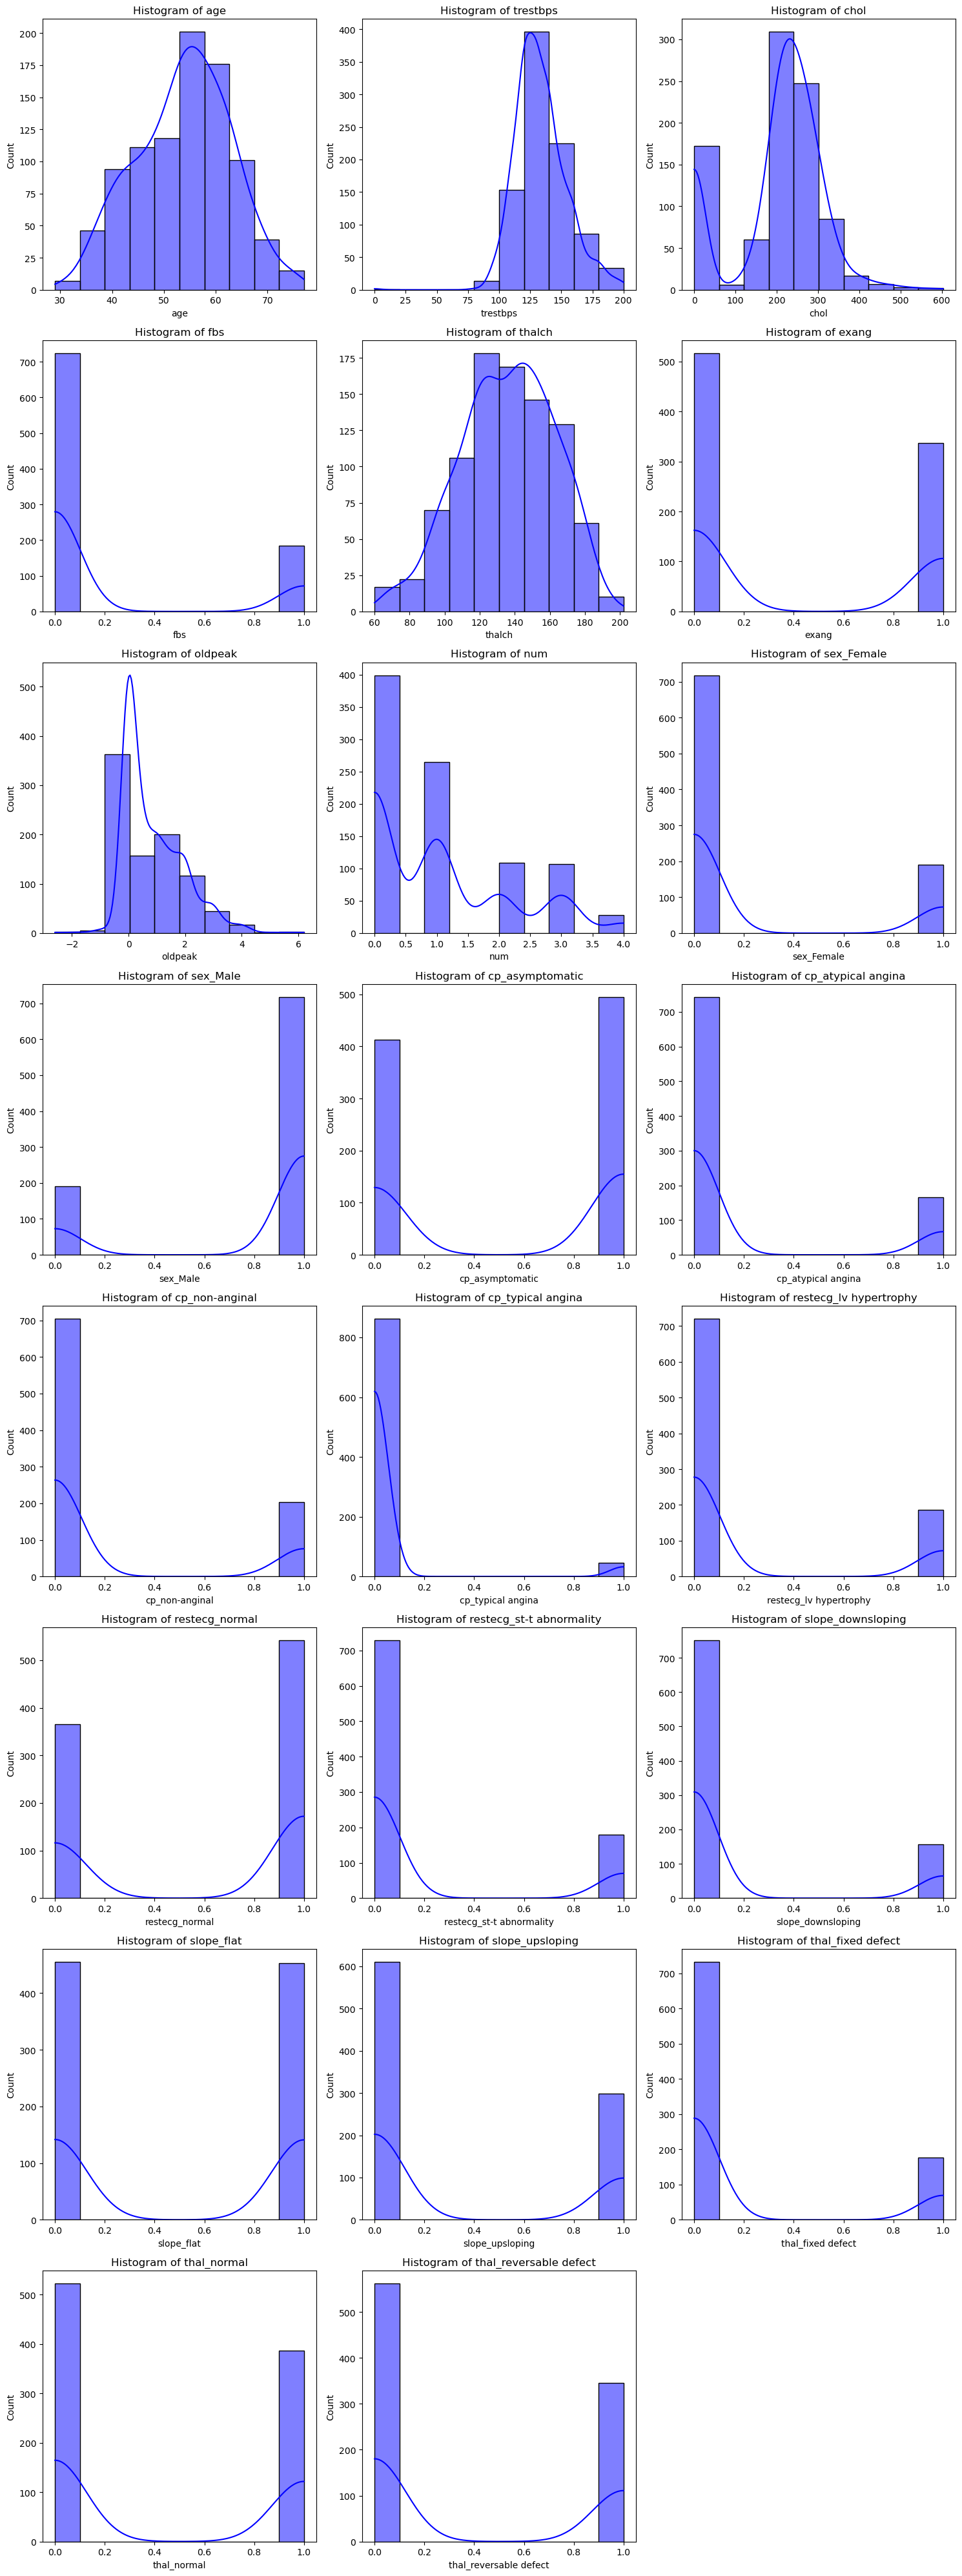

In [50]:
num_cols = len(heart_n.columns)
rows=math.ceil(num_cols/3)

plt.figure(figsize=(15, rows*5))
for i, col in enumerate(heart_n.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(heart_n[col],kde=True,bins=10,color='blue')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

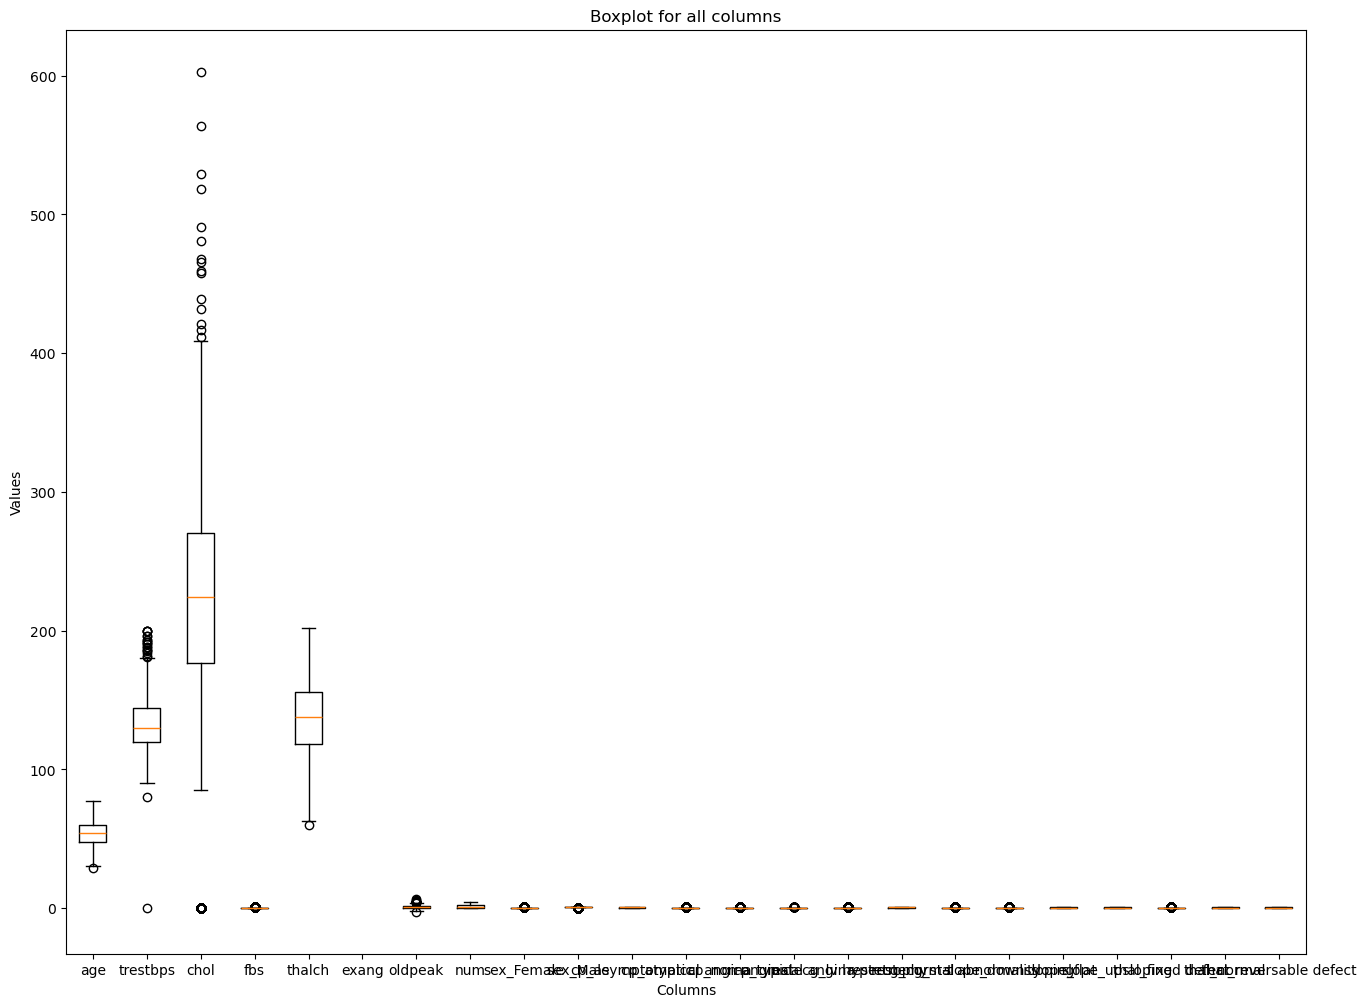

In [51]:
plt.figure(figsize=(16,12)) 
plt.boxplot([heart_n[col] for col in heart_n.columns], tick_labels=heart_n.columns)
plt.title("Boxplot for all columns")
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

In [52]:
# Removing outliers and replacing with medians



def remove_outliers_with_median(df_new_1, selected_columns):
    df_cleaned=df_new_1.copy()
    for col in selected_columns:
        Q1=df_new_1[col].quantile(0.25)
        Q3=df_new_1[col].quantile(0.75)
        IQR=Q3-Q1 #Interquartile range
        
        
#         Range of whiskers
        lower_bound=Q1-1.5*IQR 
        upper_bound=Q3+1.5*IQR
        
#         Replace outliers with median
        median_value_cleaned=df_new_1[col].median()
        df_cleaned[col]=df_new_1[col].apply(lambda x: median_value_cleaned if x<lower_bound or x>upper_bound else x)
        
    return (df_cleaned)
        
selected_columns = ['trestbps', 'chol']
df_cleaned = remove_outliers_with_median(heart_n, selected_columns)

In [53]:
heart_n.columns

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'num',
       'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina',
       'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy',
       'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping',
       'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

In [54]:
df_cleaned

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Female,sex_Male,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150,0.0,2.3,0,0,1,...,1,1,0,0,1,0,0,1,0,0
1,41,135.0,203.0,0,132,0.0,0.0,0,0,1,...,0,0,1,0,0,1,0,1,0,0
2,57,140.0,192.0,0,148,0.0,0.4,0,0,1,...,0,0,1,0,0,1,0,1,0,0
3,52,118.0,186.0,0,190,0.0,0.0,0,0,1,...,1,1,0,0,0,1,0,1,0,0
4,57,110.0,201.0,0,126,1.0,1.5,0,0,1,...,0,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,125.0,224.0,0,120,0.0,1.5,4,0,1,...,0,0,1,0,0,0,1,0,0,1
904,62,166.0,170.0,0,120,1.0,3.0,4,0,1,...,0,0,0,1,0,1,0,0,0,1
905,56,170.0,224.0,0,123,1.0,2.5,4,0,1,...,0,1,0,0,1,0,0,0,1,0
906,56,144.0,208.0,1,105,NaN,0.5,4,0,1,...,0,0,0,1,1,0,0,1,0,0


In [55]:
# After removing outliers from all the columns, the following histograms and box plots were obtained

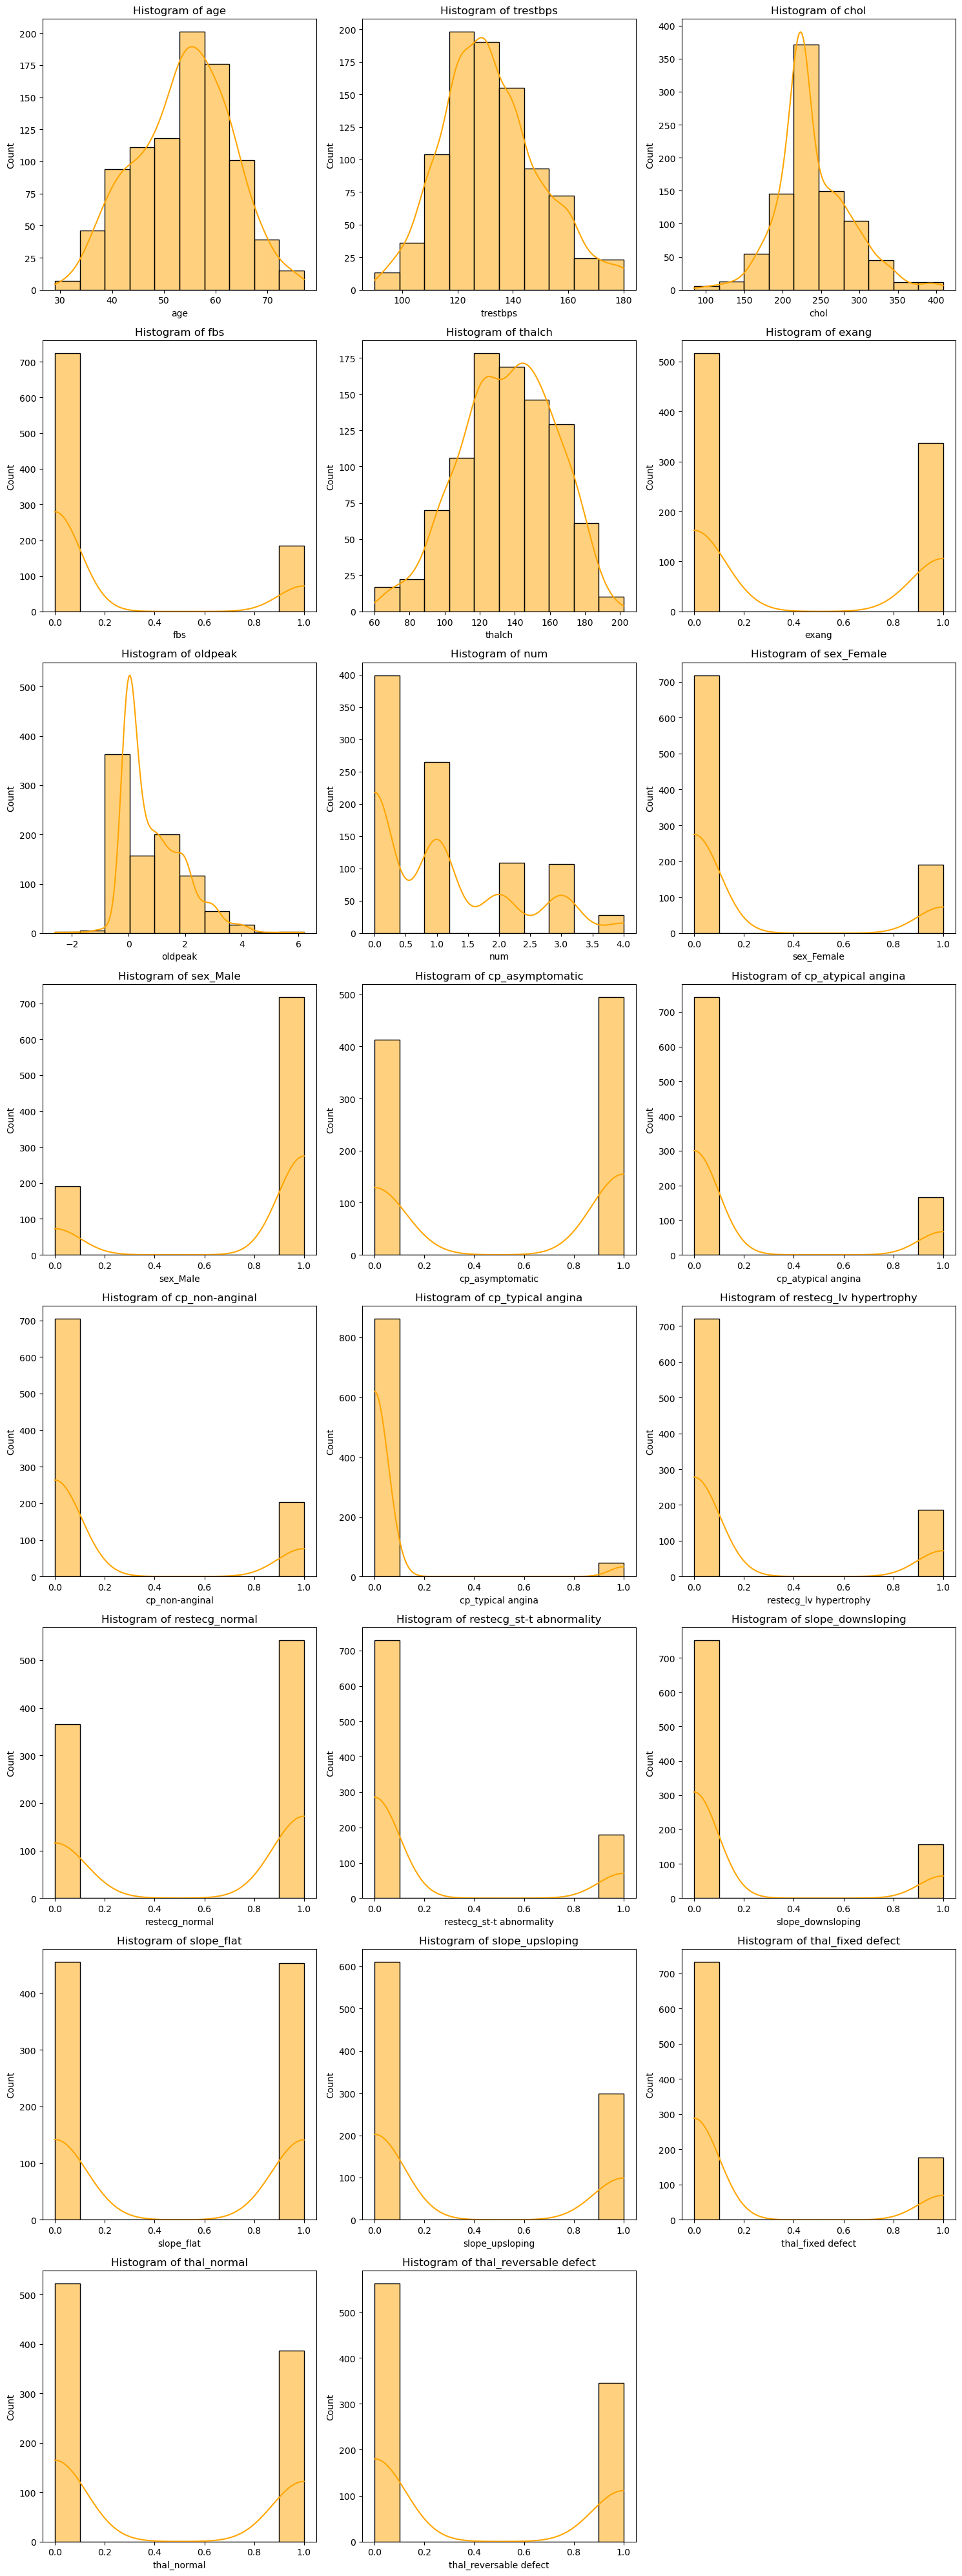

In [56]:
num_cols = len(df_cleaned.columns)
rows=math.ceil(num_cols/3)

plt.figure(figsize=(15, rows*5))
for i, col in enumerate(df_cleaned.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(df_cleaned[col],kde=True,bins=10,color='orange')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

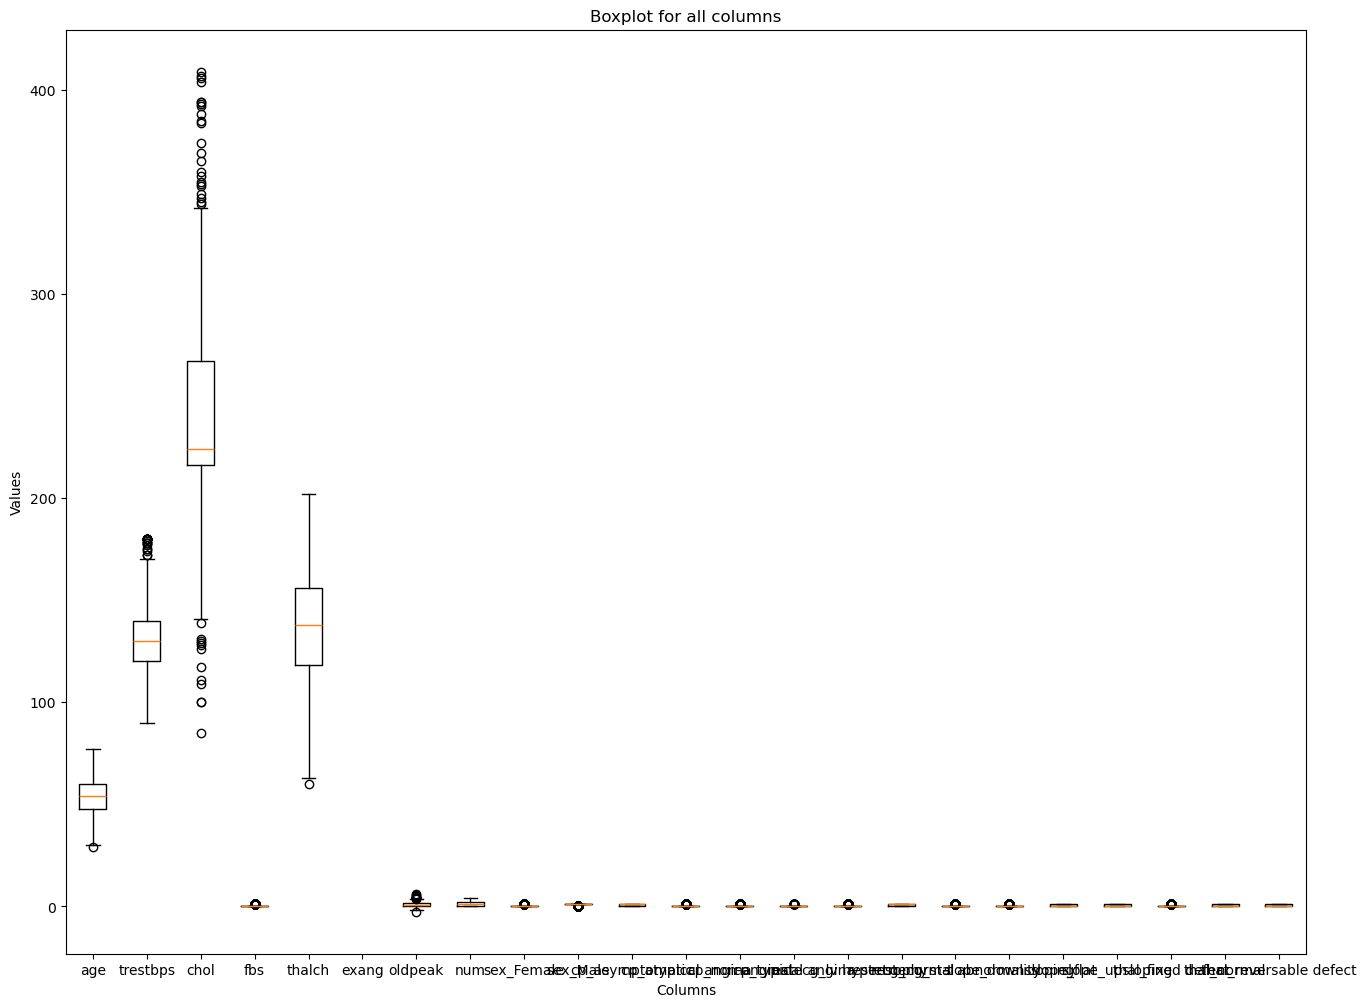

In [57]:
plt.figure(figsize=(16,12)) 
plt.boxplot([df_cleaned[col] for col in df_cleaned.columns], tick_labels=df_cleaned.columns)
plt.title("Boxplot for all columns")
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

In [58]:
# Outlier treatment completed

In [59]:
# Correlation matrices

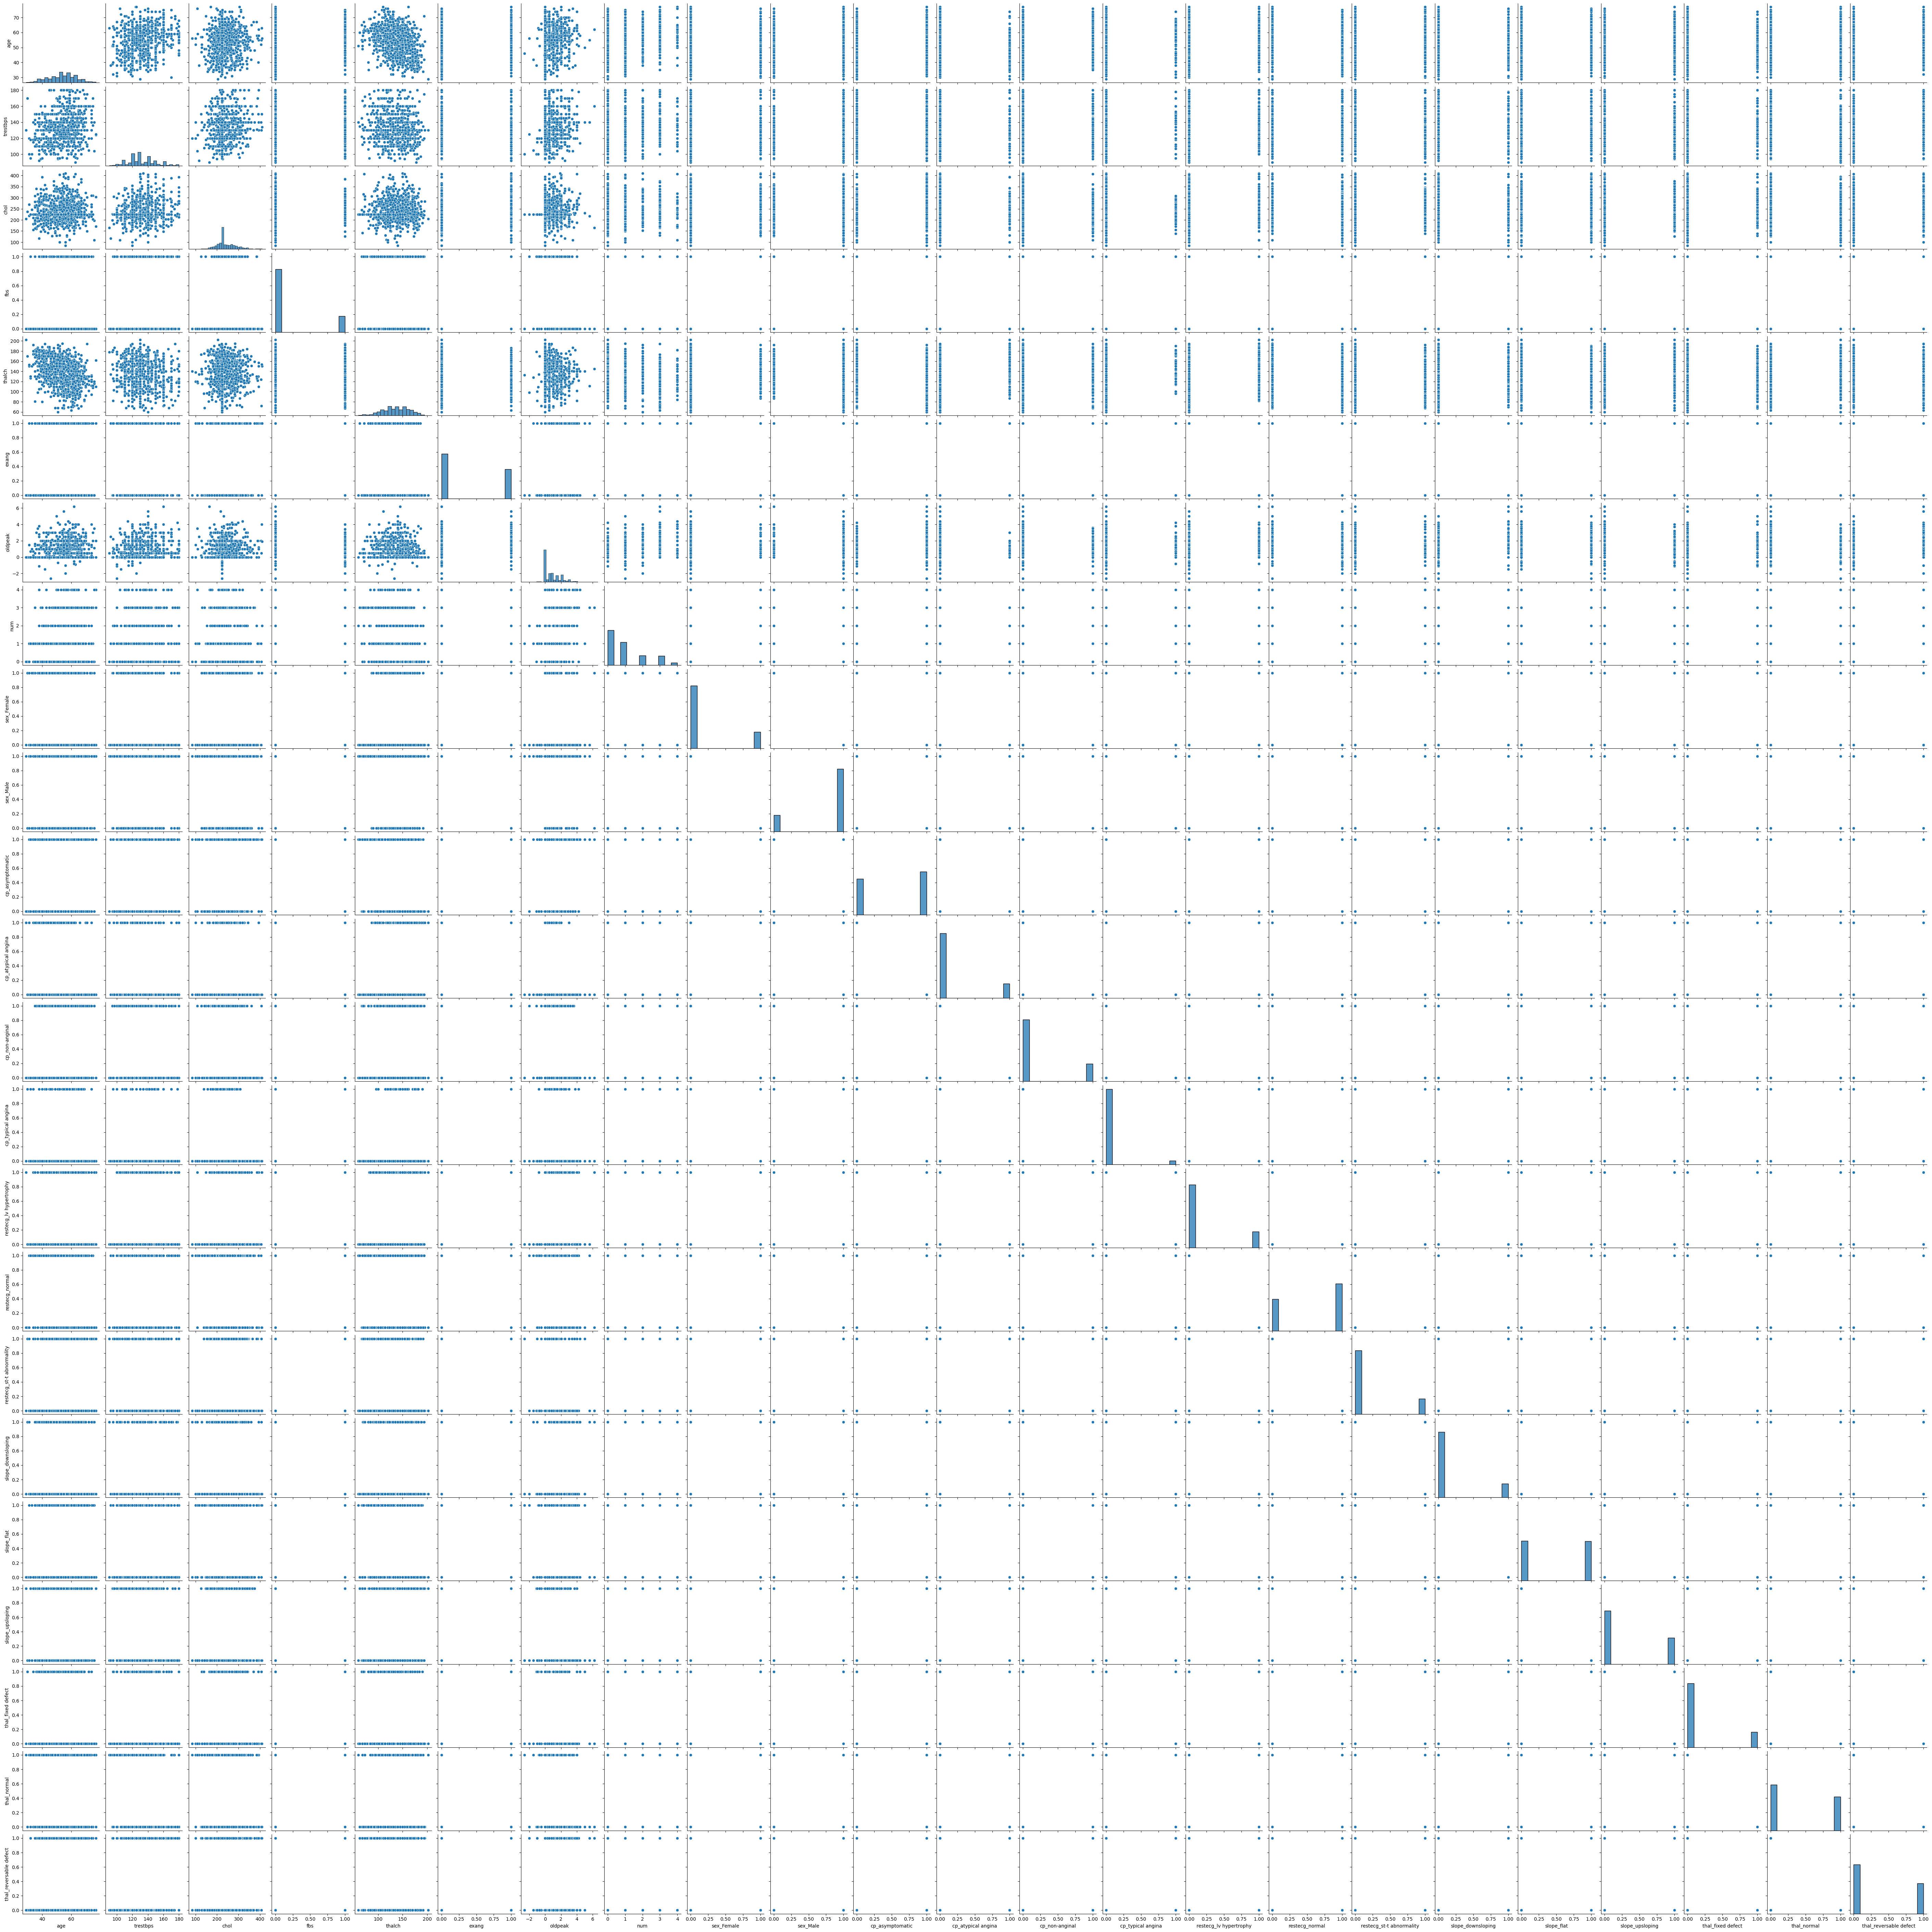

In [60]:
# Pair plots

sns.pairplot(df_cleaned)
plt.show()

In [61]:
# Correlation analysis

corr_chart=df_cleaned.corr()
corr_chart

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Female,sex_Male,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
age,1.000000,0.240370,0.044112,0.176702,-0.328088,0.184022,0.217942,0.326493,-0.052194,0.052194,...,0.036794,0.143393,-0.226702,0.133759,0.001171,0.073709,-0.079430,-0.030246,-0.038859,0.064175
trestbps,0.240370,1.000000,0.128433,0.103454,-0.102870,0.147089,0.164535,0.111333,-0.014695,0.014695,...,0.047601,0.033766,-0.110482,0.101898,-0.059523,0.070756,-0.027406,-0.019815,-0.079493,0.097048
chol,0.044112,0.128433,1.000000,-0.002081,0.020902,0.096033,0.052227,0.022522,0.111559,-0.111559,...,-0.032782,0.114260,-0.077717,-0.020320,-0.047757,0.042675,-0.006980,-0.004460,-0.012592,0.016449
fbs,0.176702,0.103454,-0.002081,1.000000,-0.065428,0.007348,0.008154,0.156268,-0.092167,0.092167,...,0.023074,0.012845,-0.108306,0.120480,0.007318,0.025723,-0.033284,0.049394,-0.053348,0.014100
thalch,-0.328088,-0.102870,0.020902,-0.065428,1.000000,-0.348398,-0.112624,-0.323058,0.178794,-0.178794,...,0.080678,0.127481,0.042430,-0.181896,-0.059382,-0.219650,0.281715,-0.109657,0.166195,-0.079920
exang,0.184022,0.147089,0.096033,0.007348,-0.348398,1.000000,0.383970,0.382434,-0.180929,0.180929,...,-0.125541,-0.012423,-0.057239,0.086542,-0.014595,0.243283,-0.248043,0.006099,-0.172476,0.170856
oldpeak,0.217942,0.164535,0.052227,0.008154,-0.112624,0.383970,1.000000,0.406078,-0.088802,0.088802,...,0.035889,0.096441,-0.096345,0.020759,0.032610,0.205259,-0.244830,0.004315,-0.147162,0.146290
num,0.326493,0.111333,0.022522,0.156268,-0.323058,0.382434,0.406078,1.000000,-0.259605,0.259605,...,-0.054996,0.072269,-0.166409,0.131716,0.027031,0.163703,-0.196087,0.013273,-0.211131,0.204115
sex_Female,-0.052194,-0.014695,0.111559,-0.092167,0.178794,-0.180929,-0.088802,-0.259605,1.000000,-1.000000,...,-0.005193,0.052691,0.014273,-0.071157,-0.027581,-0.020527,0.044070,-0.039918,0.165555,-0.136034
sex_Male,0.052194,0.014695,-0.111559,0.092167,-0.178794,0.180929,0.088802,0.259605,-1.000000,1.000000,...,0.005193,-0.052691,-0.014273,0.071157,0.027581,0.020527,-0.044070,0.039918,-0.165555,0.136034


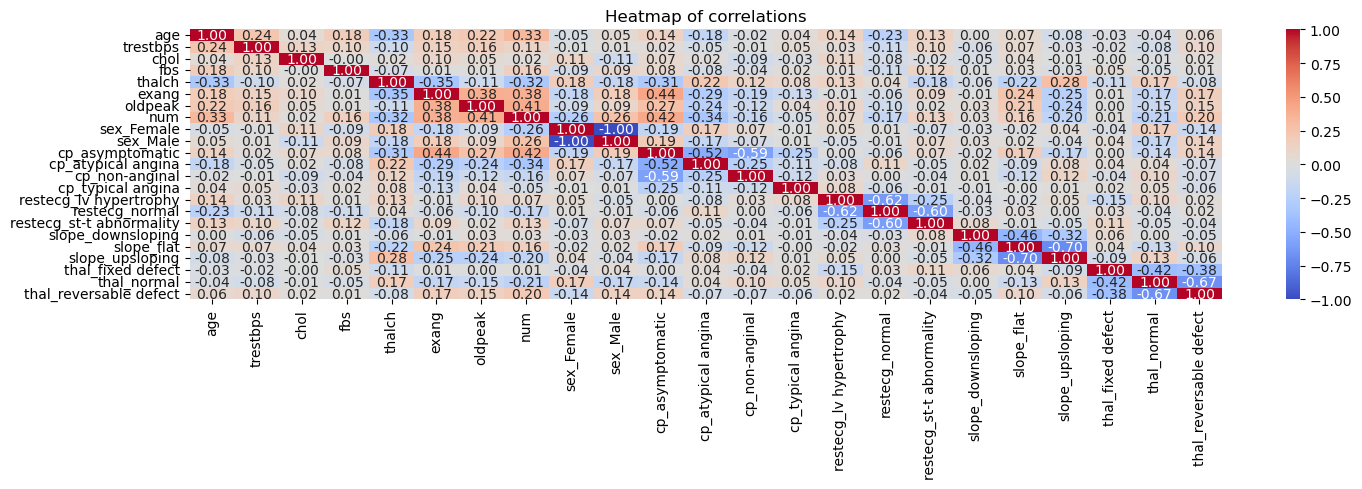

In [62]:
import seaborn as sns
plt.figure(figsize=(15, 5))
sns.heatmap(corr_chart, annot=True, cmap='coolwarm', fmt='.2f')
plt.title ('Heatmap of correlations')
plt.tight_layout()
plt.show()

In [63]:
# One of the gender column can be dropped, hence removing 'Sex_Female'


In [64]:
df_cleaned=df_cleaned.drop(['sex_Female'], axis=1)

In [65]:
df_cleaned

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_asymptomatic,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150,0.0,2.3,0,1,0,...,1,1,0,0,1,0,0,1,0,0
1,41,135.0,203.0,0,132,0.0,0.0,0,1,0,...,0,0,1,0,0,1,0,1,0,0
2,57,140.0,192.0,0,148,0.0,0.4,0,1,1,...,0,0,1,0,0,1,0,1,0,0
3,52,118.0,186.0,0,190,0.0,0.0,0,1,0,...,1,1,0,0,0,1,0,1,0,0
4,57,110.0,201.0,0,126,1.0,1.5,0,1,1,...,0,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,125.0,224.0,0,120,0.0,1.5,4,1,1,...,0,0,1,0,0,0,1,0,0,1
904,62,166.0,170.0,0,120,1.0,3.0,4,1,1,...,0,0,0,1,0,1,0,0,0,1
905,56,170.0,224.0,0,123,1.0,2.5,4,1,0,...,0,1,0,0,1,0,0,0,1,0
906,56,144.0,208.0,1,105,NaN,0.5,4,1,0,...,0,0,0,1,1,0,0,1,0,0


In [66]:
# Standardization of the data

In [67]:
from numpy import set_printoptions
from sklearn.preprocessing import MinMaxScaler

In [68]:
df_cleaned.values

array([[ 63., 145., 233., ...,   1.,   0.,   0.],
       [ 41., 135., 203., ...,   1.,   0.,   0.],
       [ 57., 140., 192., ...,   1.,   0.,   0.],
       ...,
       [ 56., 170., 224., ...,   0.,   1.,   0.],
       [ 56., 144., 208., ...,   1.,   0.,   0.],
       [ 57., 142., 277., ...,   0.,   0.,   1.]])

In [69]:
d_value = df_cleaned.values
scaler = MinMaxScaler(feature_range=(0,1))
rescaledX = scaler.fit_transform(d_value)

# Transformed data

set_printoptions(precision=3)
print (rescaledX[0:5,:]) # First 5 rows and all columns of the normalized data will be printed

[[0.708 0.611 0.457 1.    0.634 0.    0.557 0.    1.    0.    0.    0.
  1.    1.    0.    0.    1.    0.    0.    1.    0.    0.   ]
 [0.25  0.5   0.364 0.    0.507 0.    0.295 0.    1.    0.    1.    0.
  0.    0.    1.    0.    0.    1.    0.    1.    0.    0.   ]
 [0.583 0.556 0.33  0.    0.62  0.    0.341 0.    1.    1.    0.    0.
  0.    0.    1.    0.    0.    1.    0.    1.    0.    0.   ]
 [0.479 0.311 0.312 0.    0.915 0.    0.295 0.    1.    0.    0.    0.
  1.    1.    0.    0.    0.    1.    0.    1.    0.    0.   ]
 [0.583 0.222 0.358 0.    0.465 1.    0.466 0.    1.    1.    0.    0.
  0.    0.    1.    0.    0.    1.    0.    1.    0.    0.   ]]


In [70]:
rescaledX

array([[0.708, 0.611, 0.457, ..., 1.   , 0.   , 0.   ],
       [0.25 , 0.5  , 0.364, ..., 1.   , 0.   , 0.   ],
       [0.583, 0.556, 0.33 , ..., 1.   , 0.   , 0.   ],
       ...,
       [0.562, 0.889, 0.429, ..., 0.   , 1.   , 0.   ],
       [0.562, 0.6  , 0.38 , ..., 1.   , 0.   , 0.   ],
       [0.583, 0.578, 0.593, ..., 0.   , 0.   , 1.   ]])

In [71]:
df_normalized= pd.DataFrame(rescaledX, columns= df_cleaned.columns, index=df_cleaned.index)


In [72]:
df_normalized

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_asymptomatic,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,0.708333,0.611111,0.456790,1.0,0.633803,0.0,0.556818,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.250000,0.500000,0.364198,0.0,0.507042,0.0,0.295455,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.583333,0.555556,0.330247,0.0,0.619718,0.0,0.340909,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.479167,0.311111,0.311728,0.0,0.915493,0.0,0.295455,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.583333,0.222222,0.358025,0.0,0.464789,1.0,0.465909,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,0.500000,0.388889,0.429012,0.0,0.422535,0.0,0.465909,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
904,0.687500,0.844444,0.262346,0.0,0.422535,1.0,0.636364,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
905,0.562500,0.888889,0.429012,0.0,0.443662,1.0,0.579545,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
906,0.562500,0.600000,0.379630,1.0,0.316901,NaN,0.352273,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [73]:
# Scaling performed

In [74]:
# Decision Tree Classification

In [75]:
# Rearranging the columns so that the target columns move to the end of the dataframe

In [76]:
columns = df_cleaned.columns.tolist()
new_order = columns[:7] + columns[8:] + columns[7:8]  # First two + remaining + last three
df_cleaned = df_cleaned[new_order]

print(df_cleaned)

     age  trestbps   chol  fbs  thalch  exang  oldpeak  sex_Male  \
0     63     145.0  233.0    1     150    0.0      2.3         1   
1     41     135.0  203.0    0     132    0.0      0.0         1   
2     57     140.0  192.0    0     148    0.0      0.4         1   
3     52     118.0  186.0    0     190    0.0      0.0         1   
4     57     110.0  201.0    0     126    1.0      1.5         1   
..   ...       ...    ...  ...     ...    ...      ...       ...   
903   53     125.0  224.0    0     120    0.0      1.5         1   
904   62     166.0  170.0    0     120    1.0      3.0         1   
905   56     170.0  224.0    0     123    1.0      2.5         1   
906   56     144.0  208.0    1     105    NaN      0.5         1   
907   57     142.0  277.0    1     182    NaN      0.5         1   

     cp_asymptomatic  cp_atypical angina  ...  restecg_lv hypertrophy  \
0                  0                   0  ...                       1   
1                  0                 

In [77]:
df_cleaned

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_asymptomatic,cp_atypical angina,...,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,num
0,63,145.0,233.0,1,150,0.0,2.3,1,0,0,...,1,0,0,1,0,0,1,0,0,0
1,41,135.0,203.0,0,132,0.0,0.0,1,0,1,...,0,1,0,0,1,0,1,0,0,0
2,57,140.0,192.0,0,148,0.0,0.4,1,1,0,...,0,1,0,0,1,0,1,0,0,0
3,52,118.0,186.0,0,190,0.0,0.0,1,0,0,...,1,0,0,0,1,0,1,0,0,0
4,57,110.0,201.0,0,126,1.0,1.5,1,1,0,...,0,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,125.0,224.0,0,120,0.0,1.5,1,1,0,...,0,1,0,0,0,1,0,0,1,4
904,62,166.0,170.0,0,120,1.0,3.0,1,1,0,...,0,0,1,0,1,0,0,0,1,4
905,56,170.0,224.0,0,123,1.0,2.5,1,0,0,...,1,0,0,1,0,0,0,1,0,4
906,56,144.0,208.0,1,105,NaN,0.5,1,0,0,...,0,0,1,1,0,0,1,0,0,4


In [78]:
df_cleaned.isnull().sum()

age                          0
trestbps                     0
chol                         0
fbs                          0
thalch                       0
exang                       55
oldpeak                      0
sex_Male                     0
cp_asymptomatic              0
cp_atypical angina           0
cp_non-anginal               0
cp_typical angina            0
restecg_lv hypertrophy       0
restecg_normal               0
restecg_st-t abnormality     0
slope_downsloping            0
slope_flat                   0
slope_upsloping              0
thal_fixed defect            0
thal_normal                  0
thal_reversable defect       0
num                          0
dtype: int64

In [79]:
df_cleaned['exang'].median()

0.0

In [80]:
df_cleaned['exang'].value_counts()

exang
0.0    516
1.0    337
Name: count, dtype: int64

In [81]:
# Since there are only two values under this column, in order to avoid bias, the 55 null values are removed

In [82]:
df_cleaned=df_cleaned.dropna(subset=['exang'])

In [83]:
df_cleaned.isnull().sum()

age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
sex_Male                    0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
thal_fixed defect           0
thal_normal                 0
thal_reversable defect      0
num                         0
dtype: int64

In [84]:
df_cleaned.shape

(853, 22)

In [85]:
# Removed all null values


In [86]:
# Split the dataset into training and testing sets (e.g., using an 80-20 split).

In [87]:
X=df_cleaned.iloc[:,:-1]

In [88]:
Y=df_cleaned.iloc[:,-1:]

In [89]:
Y

,num
0,0
1,0
2,0
3,0
4,0
...,...
901,4
902,4
903,4
904,4


In [90]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2,random_state=40)
# test_size=0.2 mean 80 by 20 split where 20% of data will be considered as test and remaining as training data. 

In [91]:
x_train.shape

(682, 21)

In [92]:
x_test.shape

(171, 21)

In [93]:
y_test.shape

(171, 1)

In [94]:
y_train.shape

(682, 1)

In [95]:
# Building decision tree classifier using Entropy criteria

In [96]:
model = DecisionTreeClassifier(criterion = 'entropy',max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [97]:
Y.value_counts()

num
0      379
1      252
2      102
3       94
4       26
Name: count, dtype: int64

In [98]:
X.columns

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal',
       'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

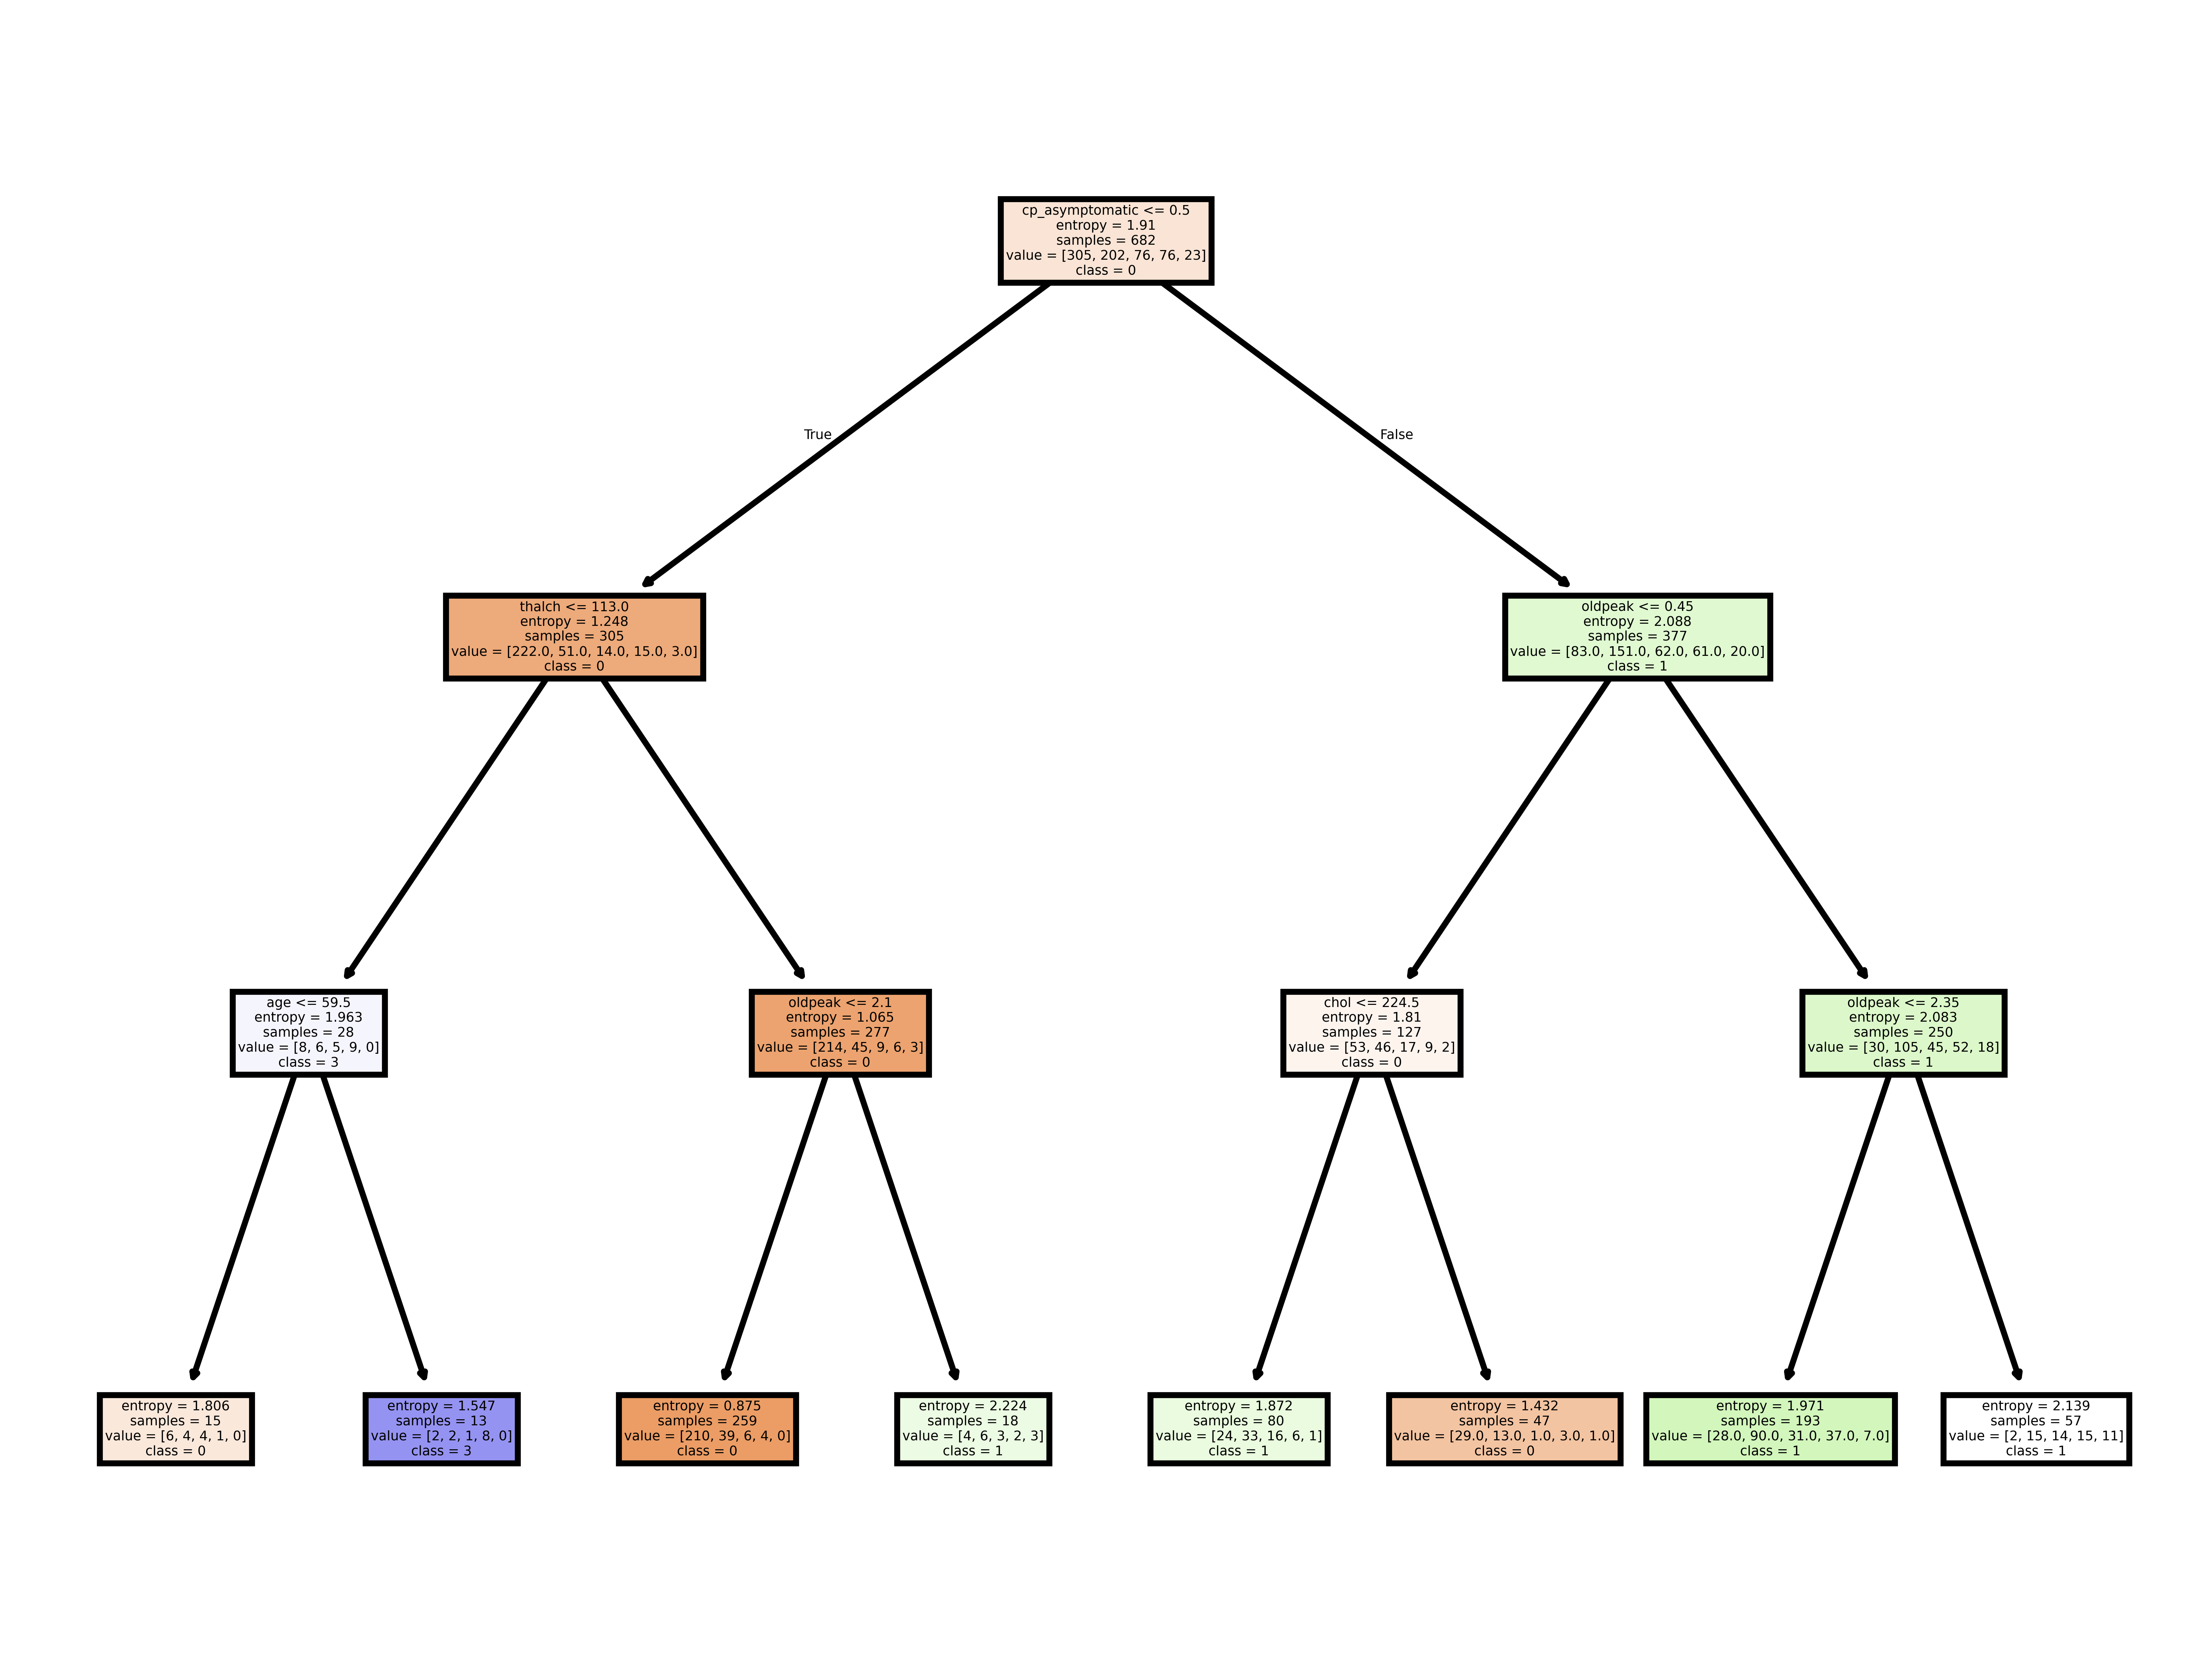

In [99]:
fn=['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal',
       'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect']
cn=["0", "1", "2", "3", "4"]
plt.figure(dpi=1200)
tree.plot_tree(model,
               feature_names = fn, 
               class_names=cn,
               filled = True);

In [100]:
# Evaluating the performance using the model by predciting y value of x_test 

In [101]:
#Predicting on test data
preds = model.predict(x_test) # predicting on test data set 
# pd.Series(preds).value_counts() # getting the count of each category 
preds

array([0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 3, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 3, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1], dtype=int64)

In [102]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.69      0.81      0.75        74
           1       0.39      0.64      0.48        50
           2       0.00      0.00      0.00        26
           3       0.50      0.06      0.10        18
           4       0.00      0.00      0.00         3

    accuracy                           0.54       171
   macro avg       0.32      0.30      0.27       171
weighted avg       0.47      0.54      0.47       171



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [103]:
# Accuracy 


In [104]:
type(preds)

numpy.ndarray

In [105]:
type(y_test)

pandas.core.frame.DataFrame

In [106]:
# It is important that both should be numpy arrays. In this case there is a mismatch in datatypes.

In [107]:
accuracy = np.mean(np.array(preds)==np.array(y_test))
print ("Accuracy:", accuracy)

Accuracy: 0.3616155398242194


In [108]:
# ROC-AUC curve

In [109]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [110]:
y_test

,num
106,0
580,1
553,1
240,0
346,0
...,...
797,3
223,0
472,1
377,0


In [111]:
y_test.shape

(171, 1)

In [112]:
y_test = label_binarize(y_test, classes=[0,1,2,3,4])
# Binarize for multi-class ROC

In [113]:
n_classes=y_test.shape[1]

In [114]:
# Get the predicted probabilities

In [115]:
Y_score = model.predict_proba(x_test)

In [116]:
# Plot ROC curve for each class

In [117]:
# Converting y_test and Y_score into numpy arrays

In [118]:
y_test=np.array(y_test)
Y_score=np.array(Y_score)

In [119]:
# Y=np.array(y_test)

In [120]:
n_classes

5

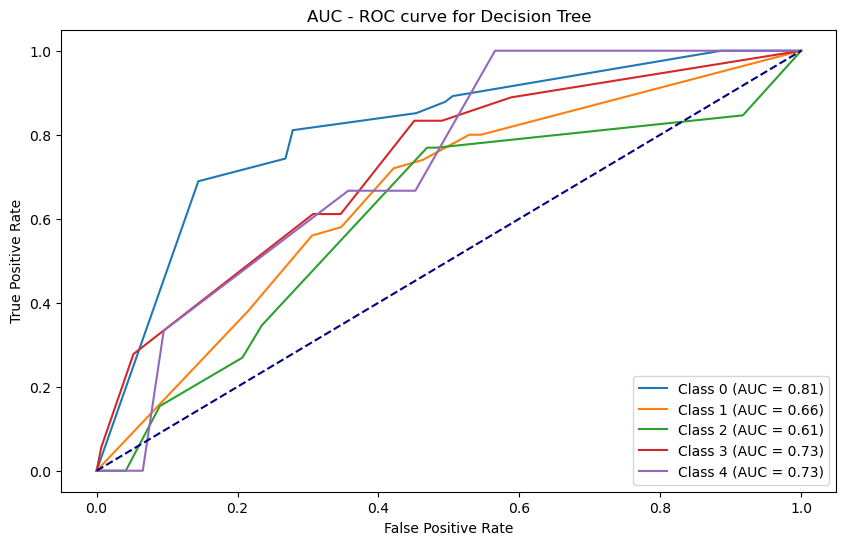

In [122]:
plt.figure(figsize=(10,6))
for i in range (n_classes):
    fpr, tpr, _ = roc_curve(y_test[:,i], Y_score[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],color='navy',linestyle='--') 
# Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC - ROC curve for Decision Tree")
plt.legend(loc='lower right')
plt.show()

In [208]:
from sklearn.metrics import mean_squared_error

# Evaluate the model
mse = mean_squared_error(y_test, preds)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')

Mean Squared Error: 1.1345029239766082
Root Mean Squared Error: 1.0651304727481081


In [206]:
preds

array([0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 3, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 3, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1], dtype=int64)

In [ ]:
# Hyperparameter tuning

In [124]:
dt=DecisionTreeClassifier(random_state=46)

In [126]:
from sklearn.model_selection import GridSearchCV

In [128]:
# Create the parameter grid based on the results of random search 
params = {
    'max_depth': [2,3,4,5,6],
    'min_samples_leaf': [5, 10, 20],
    "min_samples_split":[10,20,30],
    'criterion': ["gini", "entropy"]
}

In [130]:
# Instantiate the grid search model
grid_search = GridSearchCV(estimator=dt, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")

In [132]:
%%time
grid_search.fit(x_train, y_train)

Fitting 4 folds for each of 90 candidates, totalling 360 fits
CPU times: total: 2.94 s
Wall time: 33.3 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=46), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6],
                         'min_samples_leaf': [5, 10, 20],
                         'min_samples_split': [10, 20, 30]},
             scoring='accuracy', verbose=1)

In [133]:
score_df = pd.DataFrame(grid_search.cv_results_)
len(score_df)

90

In [134]:
score_df.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.071878,0.011190,0.050222,0.029128,gini,2,5,10,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.517647,0.535225,0.030312,70
1,0.075862,0.034555,0.031310,0.005605,gini,2,5,20,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.517647,0.535225,0.030312,70
2,0.087104,0.015993,0.055880,0.016186,gini,2,5,30,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.517647,0.535225,0.030312,70
3,0.079033,0.039495,0.081632,0.028655,gini,2,10,10,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.517647,0.535225,0.030312,70
4,0.046297,0.033487,0.046201,0.038686,gini,2,10,20,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.517647,0.535225,0.030312,70
5,0.042614,0.027733,0.044525,0.018649,gini,2,10,30,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.517647,0.535225,0.030312,70
6,0.046614,0.011965,0.051703,0.032799,gini,2,20,10,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.541176,0.541108,0.028563,53
7,0.049597,0.027084,0.043672,0.007013,gini,2,20,20,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.541176,0.541108,0.028563,53
8,0.034606,0.021660,0.032400,0.014795,gini,2,20,30,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.497076,0.549708,0.576471,0.541176,0.541108,0.028563,53
9,0.068372,0.025835,0.058859,0.010137,gini,3,5,10,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.520468,0.543860,0.576471,0.529412,0.542552,0.021287,50


In [138]:
score_df.nlargest(5,"mean_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
78,0.082548,0.011636,0.024477,0.006655,entropy,5,20,10,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.532164,0.578947,0.582353,0.576471,0.567484,0.020499,1
79,0.038139,0.014811,0.025815,0.008176,entropy,5,20,20,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.532164,0.578947,0.582353,0.576471,0.567484,0.020499,1
80,0.051517,0.029313,0.027248,0.008621,entropy,5,20,30,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.532164,0.578947,0.582353,0.576471,0.567484,0.020499,1
69,0.039948,0.009817,0.020004,0.005168,entropy,4,20,10,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.520468,0.578947,0.582353,0.558824,0.560148,0.024611,4
70,0.040251,0.011822,0.030626,0.001099,entropy,4,20,20,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.520468,0.578947,0.582353,0.558824,0.560148,0.024611,4


In [140]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=20,
                       min_samples_split=10, random_state=46)

In [142]:
dt_best = grid_search.best_estimator_

In [144]:
from sklearn.metrics import classification_report

In [146]:
type(y_test)

numpy.ndarray

In [148]:
type(x_test)

pandas.core.frame.DataFrame

In [150]:
x_test=np.array(x_test)
x_train=np.array(x_train)
y_train=np.array(y_train)

In [ ]:
# After applying Grid_Search_CV

In [152]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [154]:
# Ensure that y_test is not one-hot encoded; if it is, convert it back
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)  # Convert from one-hot to label format


In [156]:
# Create the Decision Tree model with specified parameters
dt = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=5, 
    min_samples_leaf=20, 
    min_samples_split=10, 
    random_state=46
)


In [158]:
# Fit the model
dt.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=20,
                       min_samples_split=10, random_state=46)

In [160]:
# Make predictions on the test data
y_pred = dt.predict(x_test)
y_pred_proba = dt.predict_proba(x_test)  # Predicted probabilities for ROC AUC

In [162]:
# Binarize labels for multi-class ROC AUC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Modify classes according to your dataset
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.7136920109608049


In [164]:
# Calculate and print metrics
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5263157894736842

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.82      0.71        74
           1       0.44      0.52      0.48        50
           2       0.40      0.08      0.13        26
           3       0.12      0.06      0.08        18
           4       0.00      0.00      0.00         3

    accuracy                           0.53       171
   macro avg       0.32      0.30      0.28       171
weighted avg       0.47      0.53      0.47       171



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


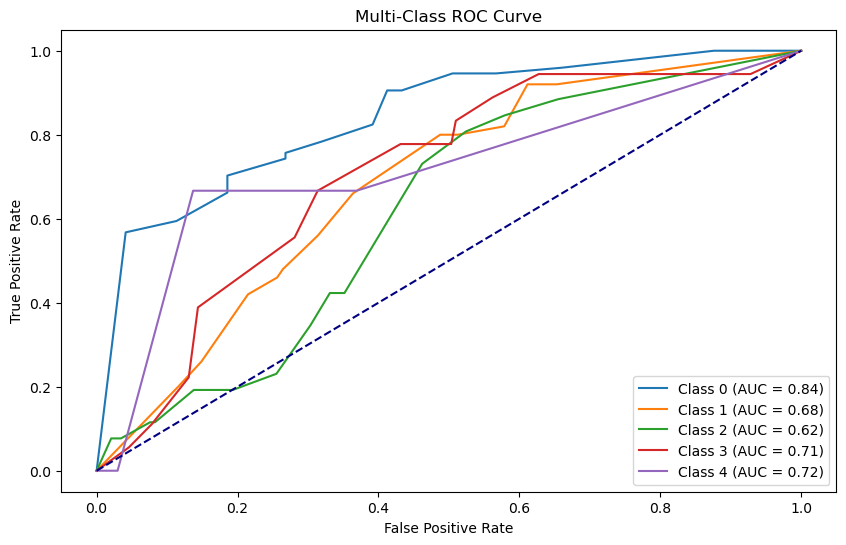

In [166]:
# Plot ROC Curve for each class
plt.figure(figsize=(10, 6))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [168]:
accuracy = np.mean(np.array(y_pred)==np.array(y_test))
print ("Accuracy:", accuracy) # Accuracy

Accuracy: 0.5263157894736842


In [182]:
type(x_train)

numpy.ndarray

In [184]:
x_train

array([[ 59., 125., 222., ...,   1.,   0.,   0.],
       [ 38., 145., 292., ...,   0.,   0.,   1.],
       [ 65., 110., 248., ...,   1.,   0.,   0.],
       ...,
       [ 48., 110., 211., ...,   1.,   0.,   0.],
       [ 66., 120., 224., ...,   1.,   0.,   0.],
       [ 54., 120., 238., ...,   0.,   1.,   0.]])

In [188]:
X.columns

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal',
       'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

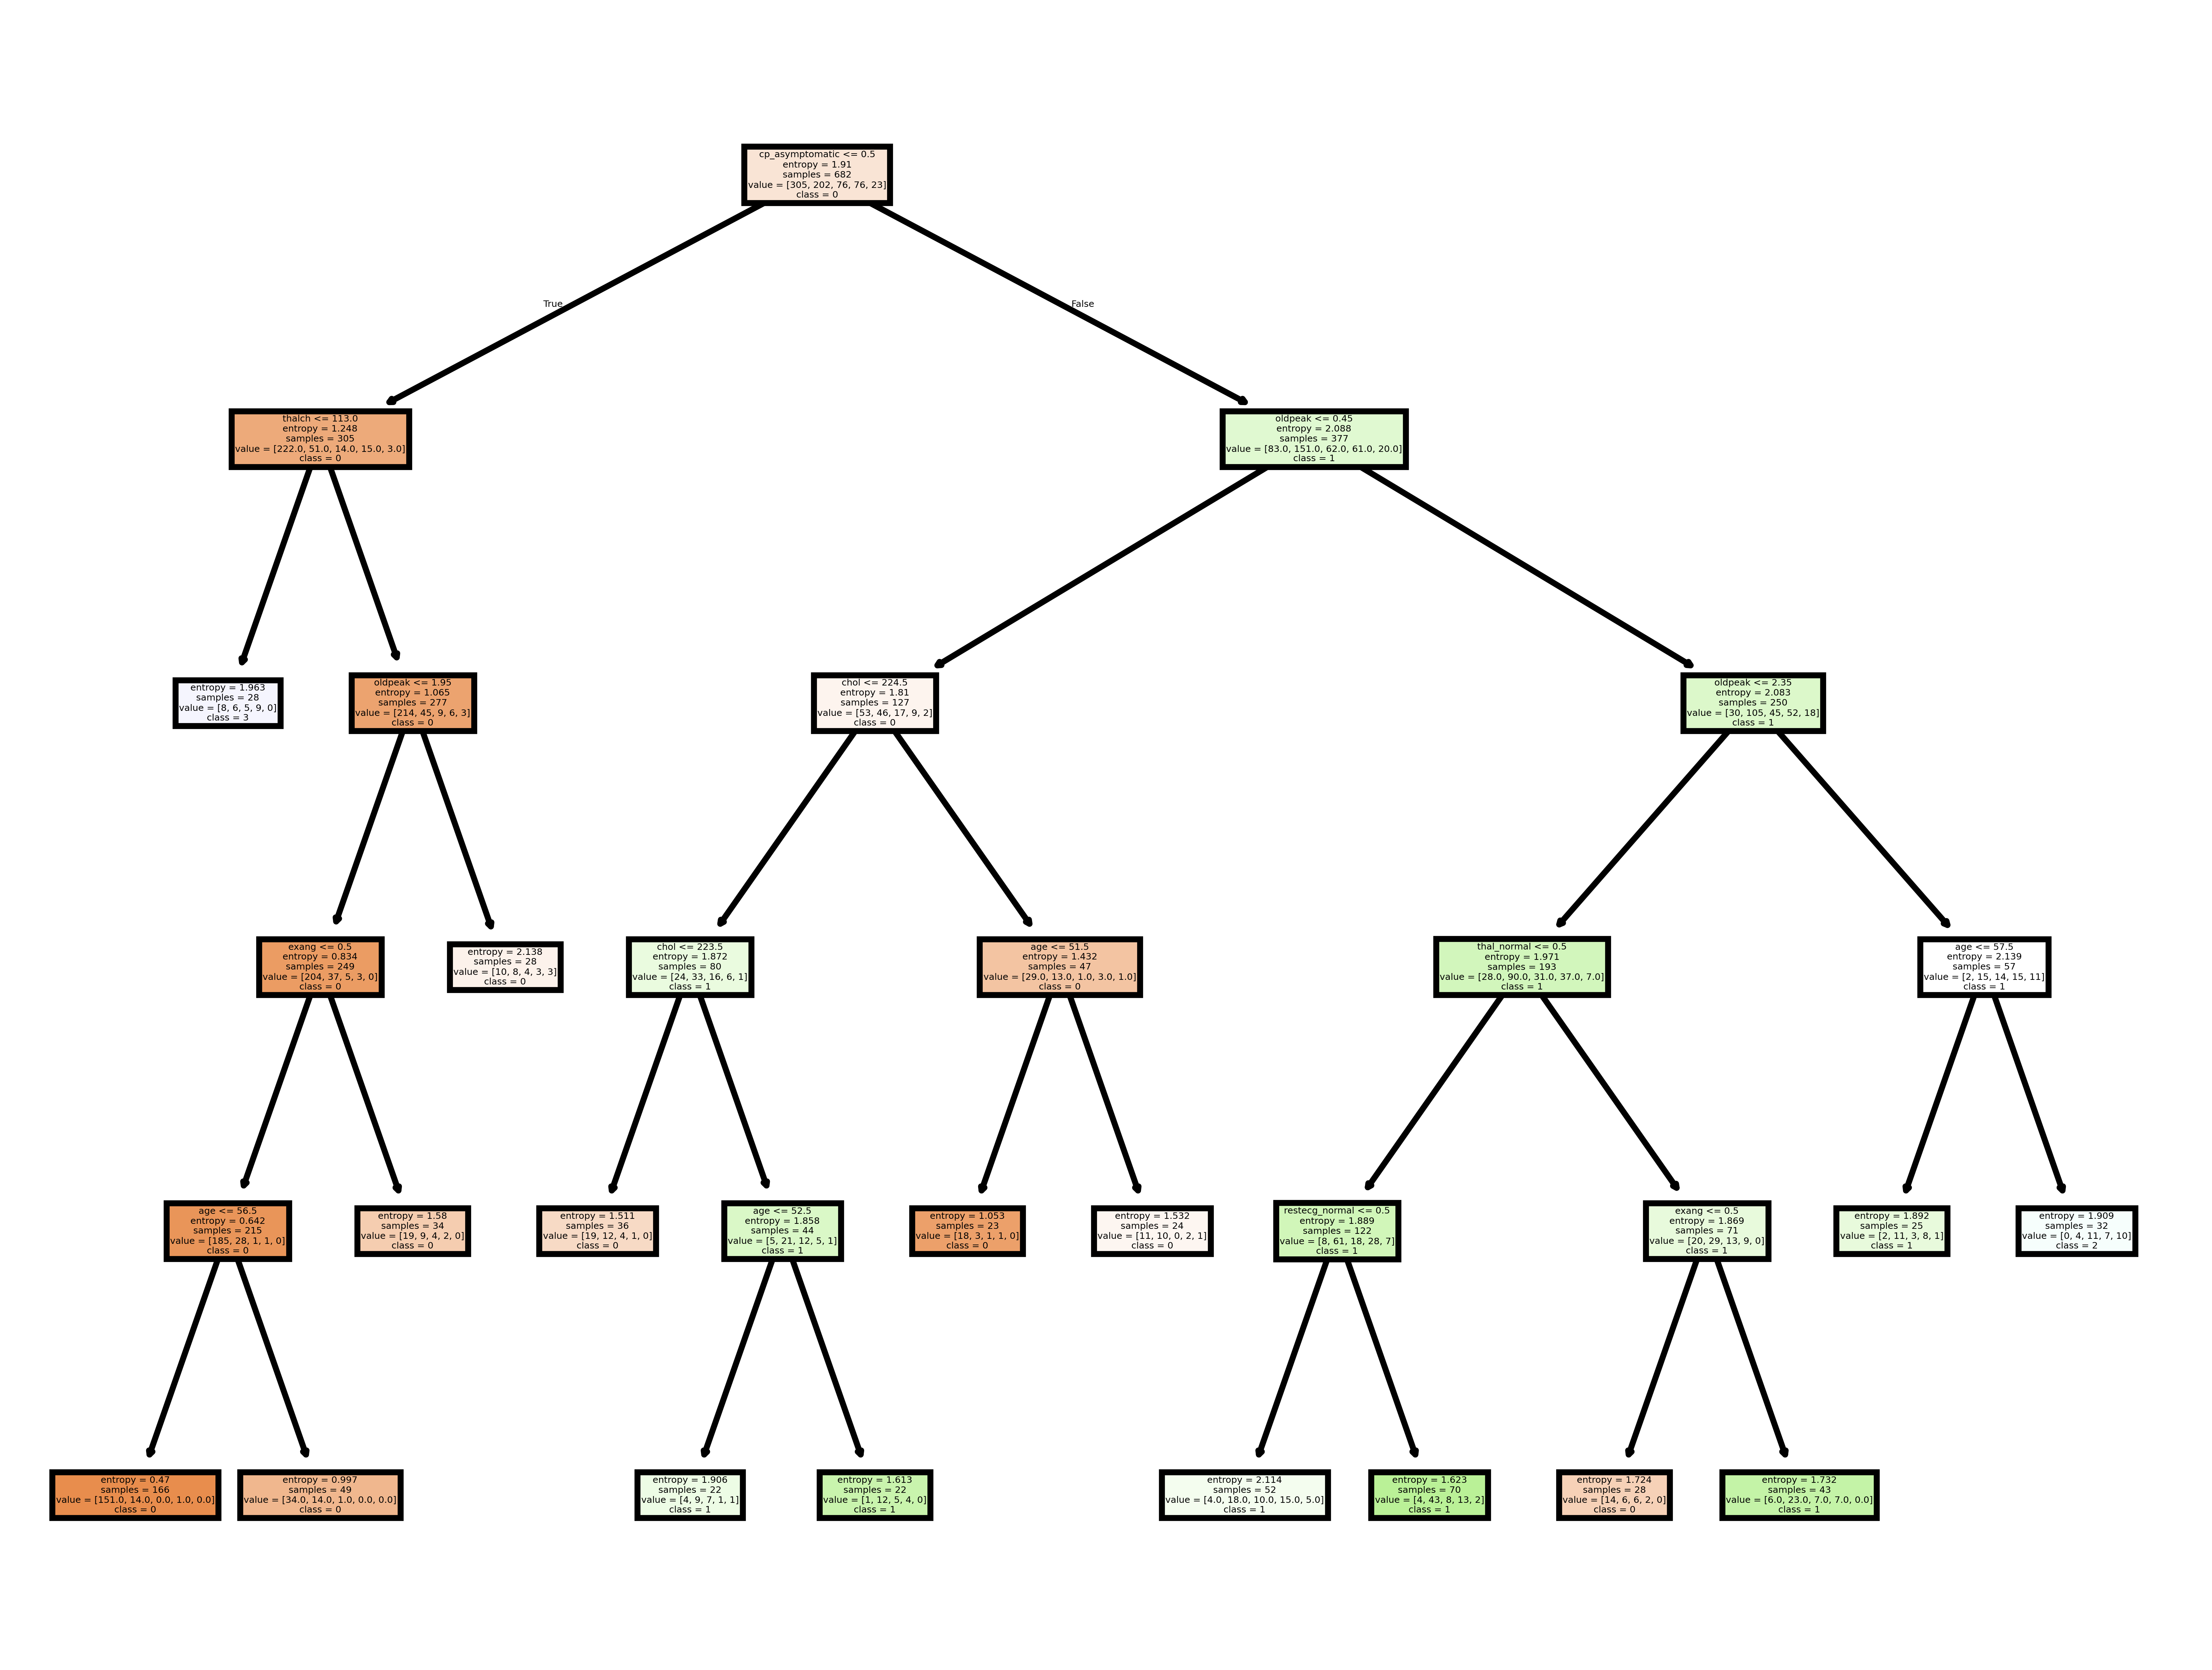

In [190]:
fn=['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal',
       'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect']
cn=["0", "1", "2", "3", "4"]
plt.figure(dpi=1200)
tree.plot_tree(dt,
               feature_names = fn, 
               class_names=cn,
               filled = True);

In [194]:
# Evaluate the model

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')

Mean Squared Error: 1.4912280701754386
Root Mean Squared Error: 1.221158495108411


In [ ]:
# Lowest RMSE is the best score, here the values are high. The model is not reliable. The model created before GridSearchCV produced better results.

In [ ]:
# Note- 

# The difference between the overall accuracy given in the classification report and the accuracy obtained by `np.mean(np.array(y_pred) == np.array(y_test))` lies in how they are calculated and the potential issues that might arise in multiclass classification:

# ---

# ### 1. Accuracy in the Classification Report 
# - How it's calculated:  
#   It is the ratio of correctly classified samples to the total number of samples.  
#   Formula:  
#   \[
#   \text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
#   \]
# - This calculation handles multiclass labels properly and ensures accurate results for each class, considering all samples.

# ---

# ### 2. Accuracy using `np.mean(np.array(y_pred) == np.array(y_test))`
# - How it works:  
#   This code compares `y_pred` and `y_test` element-wise and computes the mean of the Boolean array, where `True` indicates a match and `False` indicates a mismatch.  
#   \[
#   \text{Accuracy} = \frac{\text{Sum of (y_pred == y_test)}}{\text{Total elements in y_test}}
#   \]
# - Limitations in multiclass settings:  
#    - Shape mismatch: If `y_test` and `y_pred` are in different formats (e.g., one-hot encoded vs. integer labels), this will raise a ValueError or give incorrect results.  
#    - This method doesn't handle class weighting or any complexities of the classification report.

# ---

# ### Example to illustrate:
# - y_test = [0, 1, 2, 0, 1]
# - y_pred = [0, 1, 1, 0, 2]

# `np.mean(np.array(y_pred) == np.array(y_test))` → 0.6 (3/5 correct predictions)

# But the classification report's accuracy might be different, especially if there's class imbalance or in multilabel/multiclass cases.

# ---

# ### Why the Accuracy May Differ:
# - Multiclass Problem: If `y_test` is one-hot encoded (`(171, 5)` shape) and `y_pred` is a single-label array (`(171,)` shape), they won’t match element-wise.
# - Handling of Imbalanced Classes: The classification report gives a more reliable accuracy by considering how well each class is predicted, especially for imbalanced datasets.



In [ ]:
# 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

In [379]:
# 2. What is the difference between the Label encoding and One-hot encoding?